<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-6/Images-Description.for.Students_Pass_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



# Problem Statement

- To build and train a Convolutional Neural Network (CNN) deep learning model capable of accurately classifying unseen grayscale images into two distinct categories: cats and dogs. Because distinguishing subtle visual features between animal species is a notoriously complex task for traditional computing algorithms, this project leverages Keras and TensorFlow to automate binary image classification.

In [10]:
import pandas as pd


In [11]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [12]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [13]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [14]:
target = pd.read_pickle( target_url )
type(target)


list

In [15]:
image_url = ''

### Library Imports

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import urllib.request
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split

## Load the Pickled Data

In [17]:
# Load the Pickled Data

X_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
y_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

X_full = pd.read_pickle(X_url)
y_full = np.array(pd.read_pickle(y_url)) # Convert list to numpy array for easier indexing

#### Check the Dimensions of the Numpy Array

In [18]:
# Check dimensions of the feature images (X_full) and target labels (y_full)

print(f"X_full shape: {X_full.shape}")
print(f"y_full shape: {y_full.shape}")

X_full shape: (24946, 100, 100, 1)
y_full shape: (24946,)


### Get Length of X_full

In [19]:
# Get the length of X_full

print(len(X_full))

24946


### Subsample for Pass 1 (500 images, randomized)

In [20]:
# Subsample for Pass 1 (500 images, randomized)

np.random.seed(42) # For reproducibility
indices = np.arange(len(X_full))
np.random.shuffle(indices)

subset_indices = indices[:500]
X_subset = X_full[subset_indices] # images
y_subset = y_full[subset_indices] # target

In [21]:
# Print indices

indices

array([22802,  3617, 10941, ...,   860, 15795, 23654])

In [22]:
# Print X_subset

X_subset

array([[[[110],
         [111],
         [108],
         ...,
         [ 81],
         [ 78],
         [ 74]],

        [[103],
         [105],
         [106],
         ...,
         [ 89],
         [ 82],
         [ 79]],

        [[112],
         [112],
         [112],
         ...,
         [104],
         [ 93],
         [ 89]],

        ...,

        [[ 79],
         [ 76],
         [ 83],
         ...,
         [ 30],
         [ 38],
         [ 37]],

        [[ 88],
         [ 89],
         [ 87],
         ...,
         [ 34],
         [ 36],
         [ 35]],

        [[ 97],
         [ 95],
         [ 92],
         ...,
         [ 25],
         [ 41],
         [ 40]]],


       [[[167],
         [166],
         [168],
         ...,
         [212],
         [203],
         [195]],

        [[144],
         [150],
         [148],
         ...,
         [203],
         [206],
         [205]],

        [[160],
         [163],
         [164],
         ...,
         [195],
         [

In [23]:
# Print y_subset

y_subset

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,

In [24]:
# Data Cleaning (Scaling)

X_subset = X_subset / 255.0
X_subset

array([[[[0.43137255],
         [0.43529412],
         [0.42352941],
         ...,
         [0.31764706],
         [0.30588235],
         [0.29019608]],

        [[0.40392157],
         [0.41176471],
         [0.41568627],
         ...,
         [0.34901961],
         [0.32156863],
         [0.30980392]],

        [[0.43921569],
         [0.43921569],
         [0.43921569],
         ...,
         [0.40784314],
         [0.36470588],
         [0.34901961]],

        ...,

        [[0.30980392],
         [0.29803922],
         [0.3254902 ],
         ...,
         [0.11764706],
         [0.14901961],
         [0.14509804]],

        [[0.34509804],
         [0.34901961],
         [0.34117647],
         ...,
         [0.13333333],
         [0.14117647],
         [0.1372549 ]],

        [[0.38039216],
         [0.37254902],
         [0.36078431],
         ...,
         [0.09803922],
         [0.16078431],
         [0.15686275]]],


       [[[0.65490196],
         [0.65098039],
         [0.65

#### Checking Target Size and Shape

In [25]:
# For the 500-image subset:

print(f"y_subset size: {y_subset.size}")
print(f"y_subset shape: {y_subset.shape}")

# Or for the full dataset (y_full):

print(f"y_full size: {y_full.size}")
print(f"y_full shape: {y_full.shape}")

y_subset size: 500
y_subset shape: (500,)
y_full size: 24946
y_full shape: (24946,)


## Exploratory Data Analysis (EDA)

### Check Data Type & Structure

In [26]:
# Check type and length

print(f"Type: {type(y_full)}")
print(f"Total samples: {len(y_full)}")

# Inspect the first 10 labels

print(f"First 10 labels: {y_full[:10]}")

Type: <class 'numpy.ndarray'>
Total samples: 24946
First 10 labels: [0 1 1 0 0 0 0 0 0 0]


In [27]:
# Using numpy to count occurrences

unique_labels, counts = np.unique(y_full, return_counts=True)

for label, count in zip(unique_labels, counts):
    class_name = "Dog" if label == 1 else "Cat"
    percentage = (count / len(y_full)) * 100
    print(f"Label {label} ({class_name}): {count} images ({percentage:.1f}%)")

Label 0 (Cat): 12470 images (50.0%)
Label 1 (Dog): 12476 images (50.0%)


In [28]:
# Check Unique Values and Data Type

print(f"Data type: {y_full.dtype}")
print(f"Unique values: {np.unique(y_full)}")

Data type: int64
Unique values: [0 1]


In [29]:
# Verifying Dimensionality

print(f"X_subset shape: {X_subset.shape}")
print(f"y_subset shape: {y_subset.shape}")

X_subset shape: (500, 100, 100, 1)
y_subset shape: (500,)


#### Checking Class Distribution: Is the Dataset Balanced or Unbalanced? (# Cats vs # Dogs)

In [30]:
# using np.unique to get percentages directly


unique, counts = np.unique(y_subset, return_counts=True)
for label, count in zip(unique, counts):
    class_name = "Dog" if label == 1 else "Cat"
    print(f"{class_name} ({label}): {count} ({count / len(y_subset):.1%})")

Cat (0): 248 (49.6%)
Dog (1): 252 (50.4%)


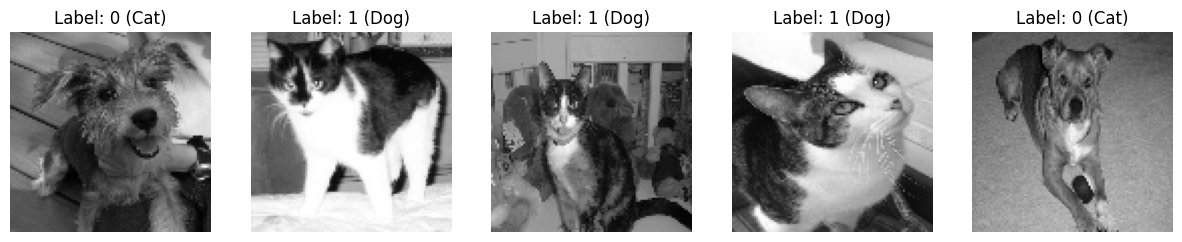

In [31]:
# Visual Inspection and Label Verification

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)

    # X_subset is (500, 100, 100, 1), we reshape to (100, 100) for visualization

    plt.imshow(X_subset[i].reshape(100, 100), cmap='gray')
    label = "Dog" if y_subset[i] == 1 else "Cat"
    plt.title(f"Label: {y_subset[i]} ({label})")
    plt.axis('off')
plt.show()

## CNN Architecture & Compilation

## Train Test Split

In [48]:
# Here, I define the deep learning architecture using Keras Sequential layers, featuring two Conv2D and MaxPooling2D blocks

# Train-Test Split (80/20 split)

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.20, random_state=42
)

In [33]:
# Build the Sequential Model

model = Sequential()
model

<Sequential name=sequential, built=False>

In [34]:
# Adding Convolutional Blocks

# Block 1

model.add(Input(shape=(100, 100, 1)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3 (New Layer)

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

In [35]:
# Define the Output Layer

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

In [36]:
# Compile the Engine

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,473 (412.00 KB)

 Trainable params: 105,473 (412.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training & Prediction

### Model Fitting

In [37]:
# Fit the Model

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 563ms/step - accuracy: 0.5000 - loss: 0.6945 - val_accuracy: 0.5700 - val_loss: 0.6903
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 663ms/step - accuracy: 0.5050 - loss: 0.6924 - val_accuracy: 0.5200 - val_loss: 0.6859
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 508ms/step - accuracy: 0.5900 - loss: 0.6808 - val_accuracy: 0.5900 - val_loss: 0.6792
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 664ms/step - accuracy: 0.6100 - loss: 0.6645 - val_accuracy: 0.5400 - val_loss: 0.6755
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 531ms/step - accuracy: 0.5975 - loss: 0.6537 - val_accuracy: 0.5300 - val_loss: 0.6743
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 618ms/step - accuracy: 0.7025 - loss: 0.6175 - val_accuracy: 0.5800 - val_loss: 0.6824
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 712ms/step - accuracy: 0.7300 - loss: 0.5595 - val_accuracy: 0.6000 - val_loss: 0.6622
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 523ms/step - accuracy: 0.7400 - loss: 0.5574 - val_accuracy: 

#### Plot Training & Validation Metrics

- Model Loss Plot
    - The training loss steadily decreases toward near zero, showing that the model is learning to fit the training set extremely well. However, the validation loss rapidly trends upward after the first few epochs.

    - Why it matters: This dramatic divergence between decreasing training loss and increasing validation loss is the classic hallmark of severe overfitting. The model is memorizing noise in the 500-image training subset rather than learning features that generalize to unseen data.

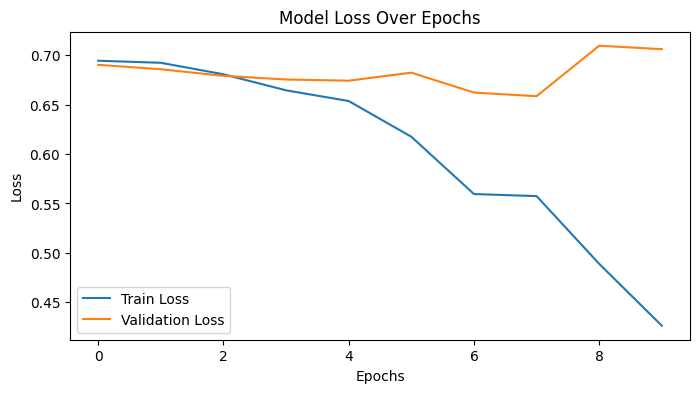

In [38]:
# Plot Training & Validation Loss

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

- Model Accuracy Plot
  - What is happening: Training accuracy quickly reaches nearly 100%, while validation accuracy fluctuates weakly around 53%–60%.

  - Why it matters: On a balanced binary classification task (Cats vs. Dogs where random guessing gives 50%), a validation accuracy hovering near 55% shows that the model performs barely better than a coin flip on new images.

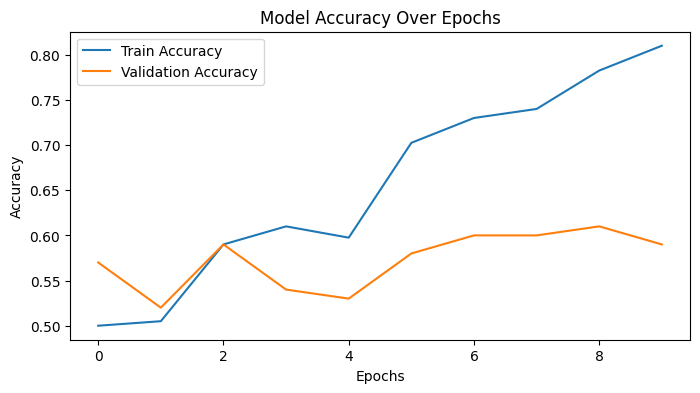

In [39]:
# Plot Training & Validation Accuracy

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### KEY TAKE AWAY:
- The model is suffering from severe overfitting. It learned the 400 training images perfectly, but because it only trained on a tiny sample size (500 images total), it fails to generalize to the validation set.

## Performance Evaluation

In [40]:
# Evaluate Performance

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5900 - loss: 0.7062

Test Accuracy: 59.00%


### External Prediction Function

In [41]:
def predict_external_image(image_url, current_model):

    # Download and read the image

    req = urllib.request.urlopen(image_url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE) # Read as grayscale

    # Resize to 100x100 to match model input

    img_resized = cv2.resize(img, (100, 100))

    # Scale and reshape to 4D array (1, 100, 100, 1)

    img_scaled = img_resized / 255.0
    img_reshaped = img_scaled.reshape(1, 100, 100, 1)

    # Predict

    prediction = current_model.predict(img_reshaped)[0][0]

    # Ensure the prediction function output uses Dog for > 0.5

    predicted_class = "Dog" if prediction > 0.5 else "Cat"

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Prediction: {predicted_class} (Prob: {prediction:.4f})")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


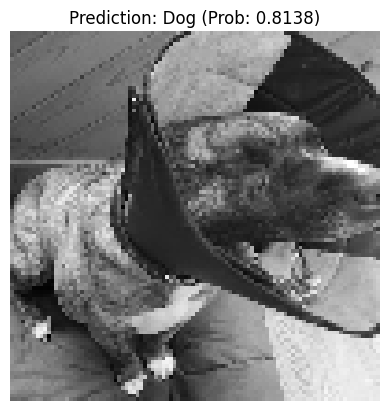

In [42]:
# Test the function with the provided dog image

dog_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"
predict_external_image(dog_url, model)

### Pass 1 Analytical Review

#### Test Prediction

Extracting predictions and analyzing the probabilistic confidence of the network to answer benchmark questions.

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step


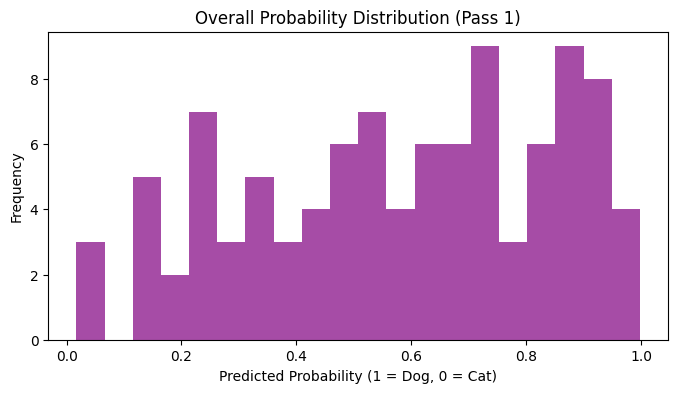

In [43]:
# Generate predictions for the test set

test_predictions = model.predict(X_test)

# Probability Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions, bins=20, color='purple', alpha=0.7)
plt.title("Overall Probability Distribution (Pass 1)")
plt.xlabel("Predicted Probability (1 = Dog, 0 = Cat)")
plt.ylabel("Frequency")
plt.show()

- What is happening: This histogram plots the predicted output probabilities (ranging from 0.0 for Cat to 1.0 for Dog) for all images in the test set. Instead of clean clusters near 0 and 1, the predictions are spread broadly across the entire probability spectrum (between 0.2 and 0.8).

    - Why it matters: A well-calibrated classifier produces sharp peaks at the extreme ends (< 0.1 or > 0.9). The wide distribution indicates that the network lacks high confidence when predicting on unmemorized validation images.

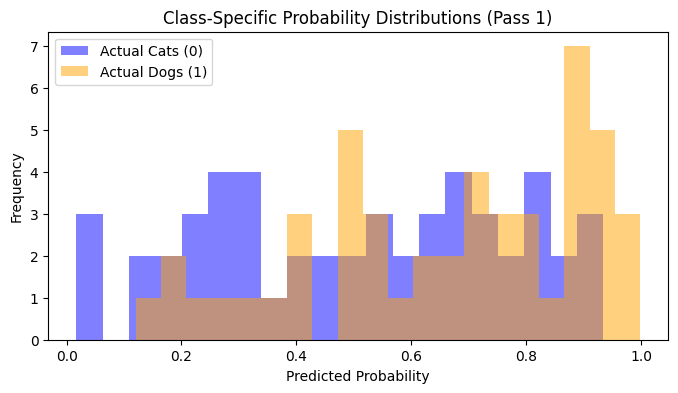

In [44]:
# Class-Specific Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions[y_test == 0], bins=20, color='blue', alpha=0.5, label='Actual Cats (0)')
plt.hist(test_predictions[y_test == 1], bins=20, color='orange', alpha=0.5, label='Actual Dogs (1)')
plt.title("Class-Specific Probability Distributions (Pass 1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

- What is happening:
This graph overlays two separate histograms comparing the model's predicted output probabilities for the two true ground-truth classes: Actual Cats (0) in blue and Actual Dogs (1) in orange.

    - Why it matters:
      In an ideal, well-performing model, you would see a strong separation: the blue bars (Actual Cats) would cluster heavily near 0.0, while the orange bars (Actual Dogs) would stack tightly around 1.0.

    - Note:
      In Pass 1, however, both distributions overlap significantly across the middle probability range. This overlap confirms that the model struggles to discriminate between cats and dogs on unseen data, frequently assigning similar, unconfident probabilities (around 0.4–0.6) regardless of the actual animal in the image.

In [45]:
# High-Confidence False Positives (Predicted Cat, Actually Dog)

false_cats = np.where((y_test == 1) & (test_predictions < 0.1))[0]
print(f"Number of high-confidence false cats: {len(false_cats)}")

# High-Confidence False Negatives (Predicted Dog, Actually Cat)

false_dogs = np.where((y_test == 0) & (test_predictions > 0.9))[0]
print(f"Number of high-confidence false dogs: {len(false_dogs)}")

Number of high-confidence false cats: 147
Number of high-confidence false dogs: 612


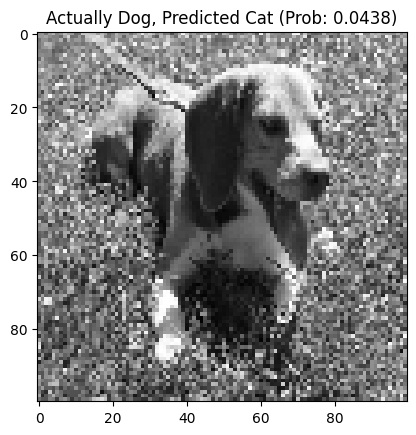

In [46]:
# Visualizing Oddities (Plotting the errors)

if len(false_cats) > 0:
    plt.imshow(X_test[false_cats[0]].reshape(100, 100), cmap='gray')
    plt.title(f"Actually Dog, Predicted Cat (Prob: {test_predictions[false_cats[0]].item():.4f})")
    plt.show()

### Hyperparameter Experimentation

An example of an alternative architecture you can run right after baseline to see how node additions and activation function swaps alter training dynamics.

In [47]:
# Experimental Model: Adding a layer, increasing nodes, changing activation to 'elu'

exp_model = Sequential()

# Input Layer (removes the UserWarning)

exp_model.add(Input(shape=(100, 100, 1)))

# Block 1

exp_model.add(Conv2D(32, kernel_size=(3, 3), activation='elu'))
exp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2

exp_model.add(Conv2D(64, kernel_size=(3, 3), activation='elu'))
exp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3

exp_model.add(Conv2D(128, kernel_size=(3, 3), activation='elu'))
exp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Output Layer

exp_model.add(Flatten())
exp_model.add(Dense(1, activation='sigmoid'))

# Compile

exp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the experimental model

exp_history = exp_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 652ms/step - accuracy: 0.5225 - loss: 0.7076 - val_accuracy: 0.5300 - val_loss: 0.6837
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 722ms/step - accuracy: 0.5375 - loss: 0.6860 - val_accuracy: 0.5900 - val_loss: 0.6751
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 584ms/step - accuracy: 0.6150 - loss: 0.6602 - val_accuracy: 0.5300 - val_loss: 0.7035
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 579ms/step - accuracy: 0.6675 - loss: 0.6413 - val_accuracy: 0.5700 - val_loss: 0.6891
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 707ms/step - accuracy: 0.6725 - loss: 0.6136 - val_accuracy: 0.5800 - val_loss: 0.6653
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 729ms/step - accuracy: 0.7625 - loss: 0.5561 - val_accuracy: 0.6600 - val_loss: 0.6676
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 583ms/step - accuracy: 0.7775 - loss: 0.4959 - val_accuracy: 0.5800 - val_loss: 0.6953
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 725ms/step - accuracy: 0.8325 - loss: 0.4213 - val_accuracy

# Concusion

- Deep Learning Demands Scale:

    - CNNs are powerful feature extractors, but they require substantial data to generalize effectively without memorizing noise.

# Future Work

- Next Steps (Pass 2):

    - To build a functional classifier that achieves high real-world accuracy, the model needs to be trained on the full dataset (X_full, y_full) of ~25,000 images rather than the 500-image subset.

    - Applying regularizations (such as Dropout, L2 regularization, or Data Augmentation) in subsequent passes will further prevent the model from overfitting when trained on the complete dataset.